In [2]:
import pandas as pd
import numpy as np

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.iloc[3]
survived = train[train['Survived'] == 1]
not_survived = train[train['Survived'] == 0]

# Inspect frequencies of each variable in survived
survived_freq = survived.describe(include='all')
print("Survived frequencies:\n", survived_freq)

# Inspect frequencies of each variable in not survived
not_survived_freq = not_survived.describe(include='all')
print("Not Survived frequencies:\n", not_survived_freq)

Survived frequencies:
         PassengerId  Survived      Pclass  \
count    342.000000     342.0  342.000000   
unique          NaN       NaN         NaN   
top             NaN       NaN         NaN   
freq            NaN       NaN         NaN   
mean     444.368421       1.0    1.950292   
std      252.358840       0.0    0.863321   
min        2.000000       1.0    1.000000   
25%      250.750000       1.0    1.000000   
50%      439.500000       1.0    2.000000   
75%      651.500000       1.0    3.000000   
max      890.000000       1.0    3.000000   

                                                     Name     Sex         Age  \
count                                                 342     342  290.000000   
unique                                                342       2         NaN   
top     Cumings, Mrs. John Bradley (Florence Briggs Th...  female         NaN   
freq                                                    1     233         NaN   
mean                           

In [4]:
train.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

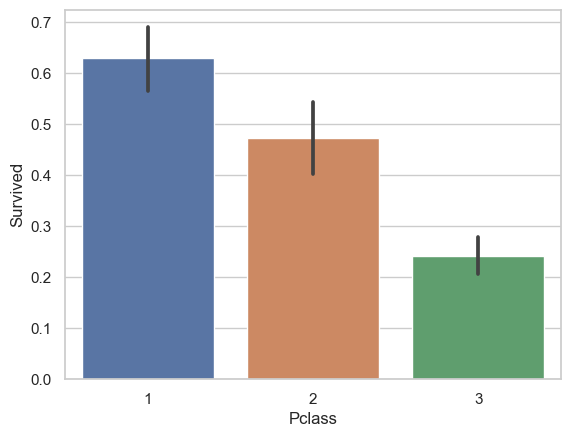

<Axes: xlabel='Pclass'>

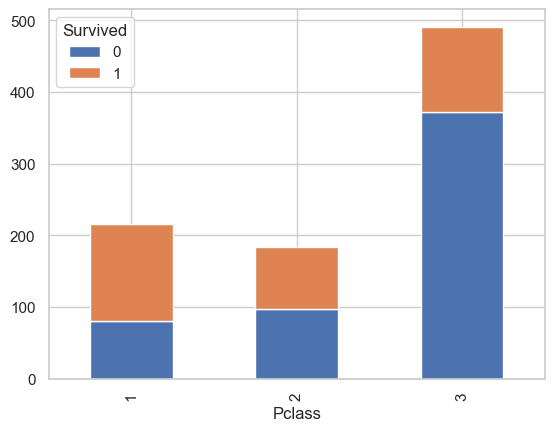

In [5]:
# create a bar plot of the Pclass variable split by the Survived column.
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
sns.barplot(x="Pclass", y="Survived", data=train)
plt.show()


# relative frequencies of the Pclass variable split by the Survived column.
train.groupby(['Pclass', 'Survived']).size().unstack().plot(kind='bar', stacked=True)

<Axes: xlabel='Sex'>

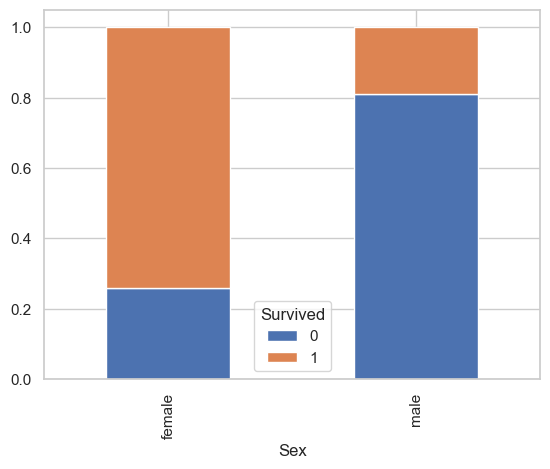

In [6]:
train['Sex'].value_counts()
# relative frequencies split by the Survived column.

train.groupby('Sex')['Survived'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)

<Axes: xlabel='Survived'>

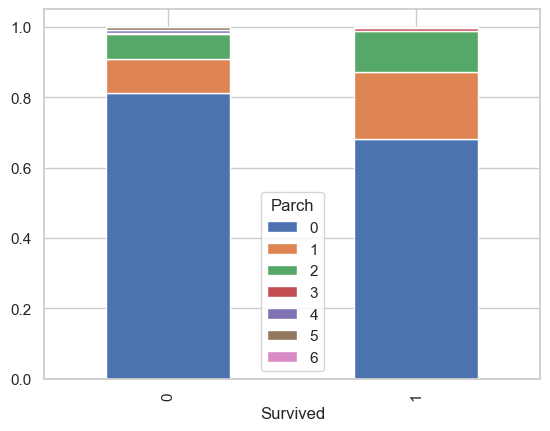

In [56]:
train.groupby('Survived')['Parch'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)

<Axes: xlabel='Survived'>

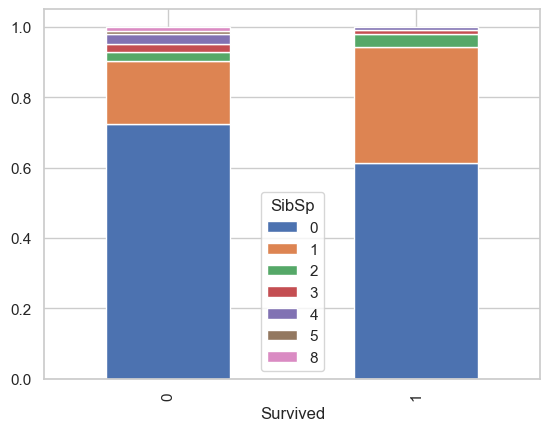

In [53]:
train.groupby('Survived')['SibSp'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)

c:\Users\Tijn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Tijn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


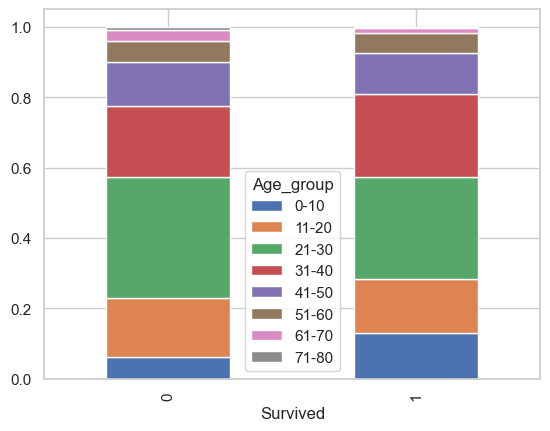

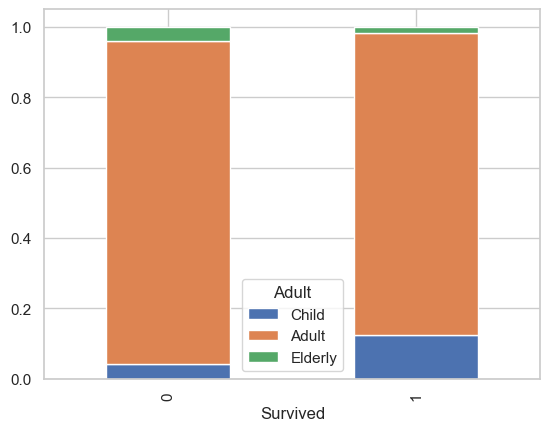

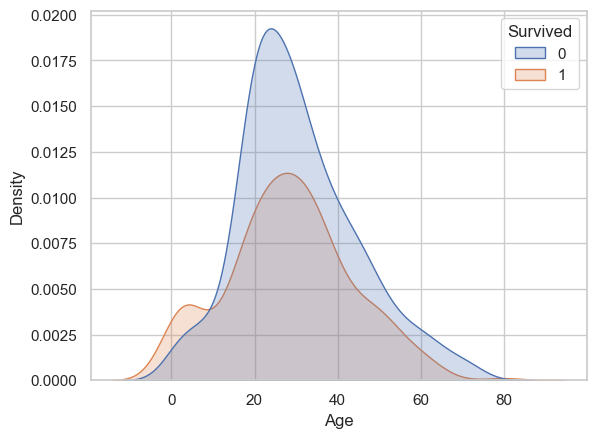

In [ ]:
# Create a new variable of age groups
train['Adult'] = pd.cut(train['Age'], bins=[0, 8, 60, np.inf], labels=['Child', 'Adult', 'Elderly'])
train['Adult'].value_counts()
train['Age_group'] = pd.cut(train['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80'])

train.groupby('Survived')['Age_group'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)

train.groupby('Survived')['Adult'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)

# create a density plot of the age variable split by the Survived column.
plt.figure()
sns.kdeplot(data=train, x='Age', hue='Survived', fill=True)
plt.show()

Feature engineering

In [55]:
train['cabin_boolean'] = train['Cabin'].notnull().astype(int)
train['Adult'] = pd.cut(train['Age'], bins=[0, 8, 60, np.inf], labels=['Child', 'Adult', 'Elderly'])
train['Age_group'] = pd.cut(train['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80'])
train['SibSp_gr_0'] = train['SibSp'] > 0
train['SibSp_gr_0']

0       True
1       True
2      False
3       True
4      False
       ...  
886    False
887    False
888     True
889    False
890    False
Name: SibSp_gr_0, Length: 891, dtype: bool